In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import OrcFxAPI
import h5py
import pandas as pd
from scipy.signal import find_peaks


In [2]:
model_path = r"C:\Users\verav\Desktop\Studie\Afstuderen\PHASe2_ORCA\Decay_opzet_harlequin.dat"
exp_path = r"C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2\Decay_data\01_Rawdata\02\002\34224_03CB_02_002_007_01_Decay1.h5m"

lookback_window = 5.0      # seconden vóór decay-start waarin we de amplitude zoeken
quiet_window_end = 12.0     # rustige periode eindigt 12 s vóór decay-start
quiet_window_length = 50.0


In [3]:
with h5py.File(exp_path, "r") as f:
    t_exp = f["CroppedSignals/time"][:]
    z_exp = f["CroppedSignals/Z_COG (LPF: 5.0 rad*s^-1)"][:]
    t_unfiltered = f["UnfilteredSignals/time"][:]
    z_unfiltered = f["UnfilteredSignals/Z_COG (unfiltered)"][:]

# DataFrames in één keer maken
df_exp = pd.DataFrame({
    "time [s]": t_exp,
    "time_norm [s]": t_exp - t_exp[0],
    "z_exp [m]": z_exp
})

df_unfiltered = pd.DataFrame({
    "time [s]": t_unfiltered,
    "z_unfiltered [m]": z_unfiltered
})


In [4]:
t_decay_start = t_exp[0]

# -----------------------------
# 2. rustige periode in ongefilterd signaal kiezen
#    van (start - quiet_window_end - quiet_window_length) tot (start - quiet_window_end)
# -----------------------------
quiet_start = t_decay_start - quiet_window_end - quiet_window_length
quiet_end = t_decay_start - quiet_window_end

mask_quiet = (t_unfiltered >= quiet_start) & (t_unfiltered <= quiet_end)

if not np.any(mask_quiet):
    raise ValueError("Geen data gevonden in de gekozen rustige periode. Kies andere vensters.")

z_eq = np.mean(z_unfiltered[mask_quiet])

# -----------------------------
# 3. zoekvenster voor initiële amplitude
#    10 s vóór decay-start
# -----------------------------
search_start = t_decay_start - lookback_window
search_end = t_decay_start

mask_search = (t_unfiltered >= search_start) & (t_unfiltered <= search_end)

if not np.any(mask_search):
    raise ValueError("Geen data gevonden in het zoekvenster vóór de decay-start.")

t_search = t_unfiltered[mask_search]
z_search = z_unfiltered[mask_search]

# afwijking t.o.v. evenwicht
deviation = z_search - z_eq

# index van grootste absolute uitslag
idx_local = np.argmax(np.abs(deviation))

t_init = t_search[idx_local]
z_init = z_search[idx_local]
A0 = np.abs(z_init - z_eq)

print(f"Decay start time           = {t_decay_start:.3f} s")
print(f"Quiet window               = [{quiet_start:.3f}, {quiet_end:.3f}] s")
print(f"Equilibrium level z_eq     = {z_eq:.6f} m")
print(f"Search window              = [{search_start:.3f}, {search_end:.3f}] s")
print(f"Initial extreme at t       = {t_init:.3f} s")
print(f"Initial extreme z          = {z_init:.6f} m")
print(f"Initial amplitude A0       = {A0:.6f} m")
print(f"Signed amplitude           = {z_init - z_eq:.6f} m")

Decay start time           = 171.794 s
Quiet window               = [109.794, 159.794] s
Equilibrium level z_eq     = 0.011367 m
Search window              = [166.794, 171.794] s
Initial extreme at t       = 168.702 s
Initial extreme z          = -2.790992 m
Initial amplitude A0       = 2.802358 m
Signed amplitude           = -2.802358 m


In [5]:
model = OrcFxAPI.Model(model_path)
constraint = model["decay_constraint"]
floaters = model["floaters"]
floatertype = model["Floatertype"]

print("A0:", A0)

print(constraint.InFrameInitialZ)

A0: 2.8023584
0.0


In [6]:
constraint.InFrameInitialZ = A0
constraint.InFrameInitialX = 0
constraint.InFrameInitialY = 0
constraint.InFrameInitialAzimuth = 0
constraint.InFrameInitialDeclination = 0 
constraint.InFrameInitialGamma = 0

floatertype.OtherDampingLinearCoeffx = 0 #surge
floatertype.OtherDampingLinearCoeffy = 0 #sway
floatertype.OtherDampingLinearCoeffz  = 0 #heav
floatertype.OtherDampingLinearCoeffRx = 0 #roll
floatertype.OtherDampingLinearCoeffRy = 0 #pitch
floatertype.OtherDampingLinearCoeffRz = 0 #yaw

floatertype.OtherDampingQuadraticCoeffx = 0 #surge
floatertype.OtherDampingQuadraticCoeffy = 0 #sway 
floatertype.OtherDampingQuadraticCoeffz = 0 #heav
floatertype.OtherDampingQuadraticCoeffRx = 0#roll
floatertype.OtherDampingQuadraticCoeffRy = 0 #pitch
floatertype.OtherDampingQuadraticCoeffRz = 0 #yaw

print(constraint.InFrameInitialZ)

2.802358388900757


In [7]:
model.RunSimulation()
print("Simulatie klaar.")

Simulatie klaar.


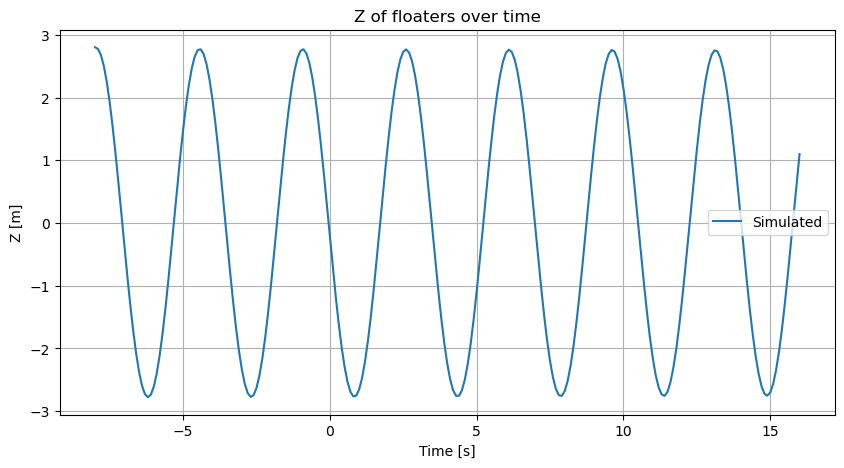

In [8]:
t_sim = model.general.TimeHistory("Time")
z_sim = floaters.TimeHistory("Z") +0.265

plt.figure(figsize=(10, 5))
plt.plot(t_sim, z_sim, label="Simulated")
plt.xlabel("Time [s]")
plt.ylabel("Z [m]")
plt.title("Z of floaters over time")
plt.grid(True)
plt.legend()
plt.show()

In [9]:
delta_t_exp = t_decay_start - t_init
print(f"Tijdsverschil tussen initiële amplitude en begin cropped decay: {delta_t_exp:.3f} s")


t_sim_shifted = t_sim - delta_t_exp - t_sim[0] 

Tijdsverschil tussen initiële amplitude en begin cropped decay: 3.093 s


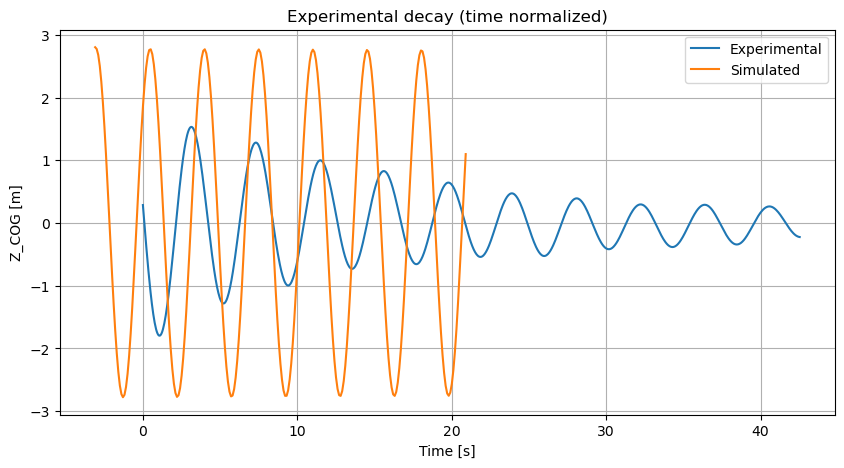

In [12]:
plt.figure(figsize=(10, 5))
plt.plot(df_exp["time_norm [s]"], df_exp["z_exp [m]"], label="Experimental")
plt.plot(t_sim_shifted, z_sim, label="Simulated")

plt.xlabel("Time [s]")
plt.ylabel("Z_COG [m]")

plt.title("Experimental decay (time normalized)")
plt.grid(True)
plt.legend()
plt.show()

NameError: name 't_sim_decay' is not defined

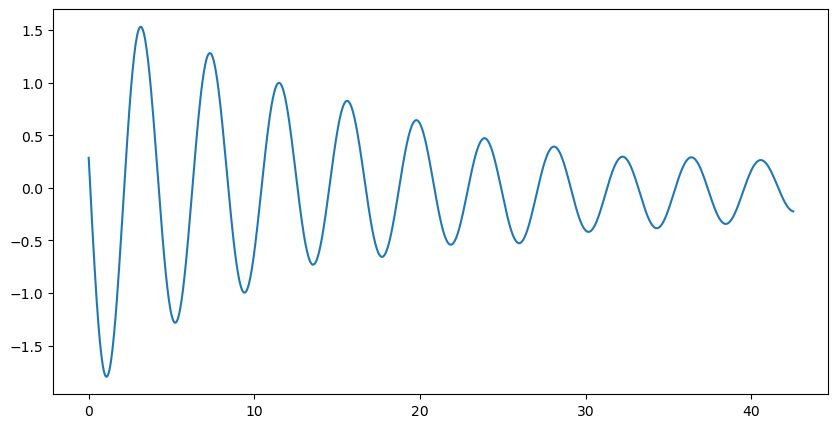

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(df_exp["time_norm [s]"], df_exp["z_exp [m]"], label="Experimental")
plt.plot(t_sim_decay, z_sim, label="Simulated")

plt.xlabel("Time [s]")
plt.ylabel("Z_COG [m]")
plt.title("Experimental decay (time normalized)")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:

dd
# troughs zoeken = peaks van het negatieve signaal
exp_trough_idx, _ = find_peaks(-z_exp)
sim_trough_idx, _ = find_peaks(-z_sim)

# eerste trough pakken
i_exp0 = exp_trough_idx[0]
i_sim0 = sim_trough_idx[0]

t_exp_trough = (t_exp - t_exp[0])[i_exp0]
t_sim_trough = t_sim_norm[i_sim0]

print("Eerste trough experiment:", t_exp_trough)
print("Eerste trough simulatie:", t_sim_trough)

NameError: name 't_sim_norm' is not defined